# Olist Delivery Delay Prediction
### Brazilian E-Commerce Public Dataset | Capstone Project
#### Notebook 01: Data Understanding and Cleaning


---

**Authors:** Sura and Aman

**Verified by:** Ameed and Ruaa

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Tracks:** Supervised Learning (Binary Classification) · Unsupervised Learning (Clustering)

---

## Problem Statement

**Late deliveries** damage customer trust, increase support costs, and lead to negative reviews.

**Business question:** Can we predict whether an order will be delivered late,
before it ships, so Olist can proactively manage at-risk orders?

**Stakeholder:** Olist Operations and Customer Experience Team

In [25]:
import os
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
ASSETS_DIR = os.path.join(NOTEBOOK_DIR, 'assets')

---

## Data Understanding

### How Olist works and how the data was captured

Olist is the largest department store in Brazilian marketplaces. It connects small 
businesses from all over Brazil to multiple sales channels through a single contract. 
Merchants sell their products through the Olist Store and ship them directly to 
customers using Olist's logistics partners.

After a customer purchases a product, the seller is notified to fulfill the order. 
Once the customer receives the product, or the estimated delivery date is due, 
the customer receives a satisfaction survey by email to rate the purchase experience 
and leave comments.

This dataset contains 100,000 orders made between 2016 and 2018 across multiple 
marketplaces in Brazil. It allows viewing each order from multiple dimensions: 
order status, price, payment, freight performance, customer location, product 
attributes, and customer reviews. The data is real but has been anonymised for 
public release.

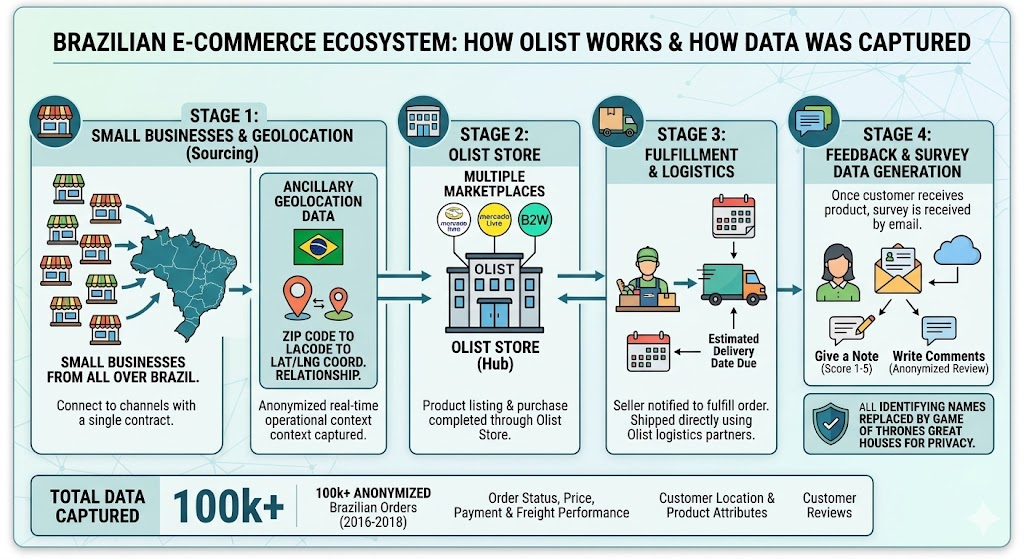

In [26]:
from IPython.display import Image, display
import os

assets = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'assets')
display(Image(filename=os.path.join(assets, 'olist_flow.jpg'), width=1000))

<div align="center">
  <p style="color: grey; font-style: italic;">
    Figure 1: Olist E-Commerce Data Lifecycle & Pipeline
  </p>
</div>

---

### Important Considerations
 As per the dataset documentation and marketplace architecture...
* **Order Composition:** An order might have multiple items.
* **Fulfillment:** Each item might be fulfilled by a distinct seller.
* **Anonymization:** All text identifying stores and partners were replaced by the names of **Game of Thrones** great houses.

---

### Contextual Reference
To better understand how the data was captured at the source, the following is an example of a live product listing on the marketplace:

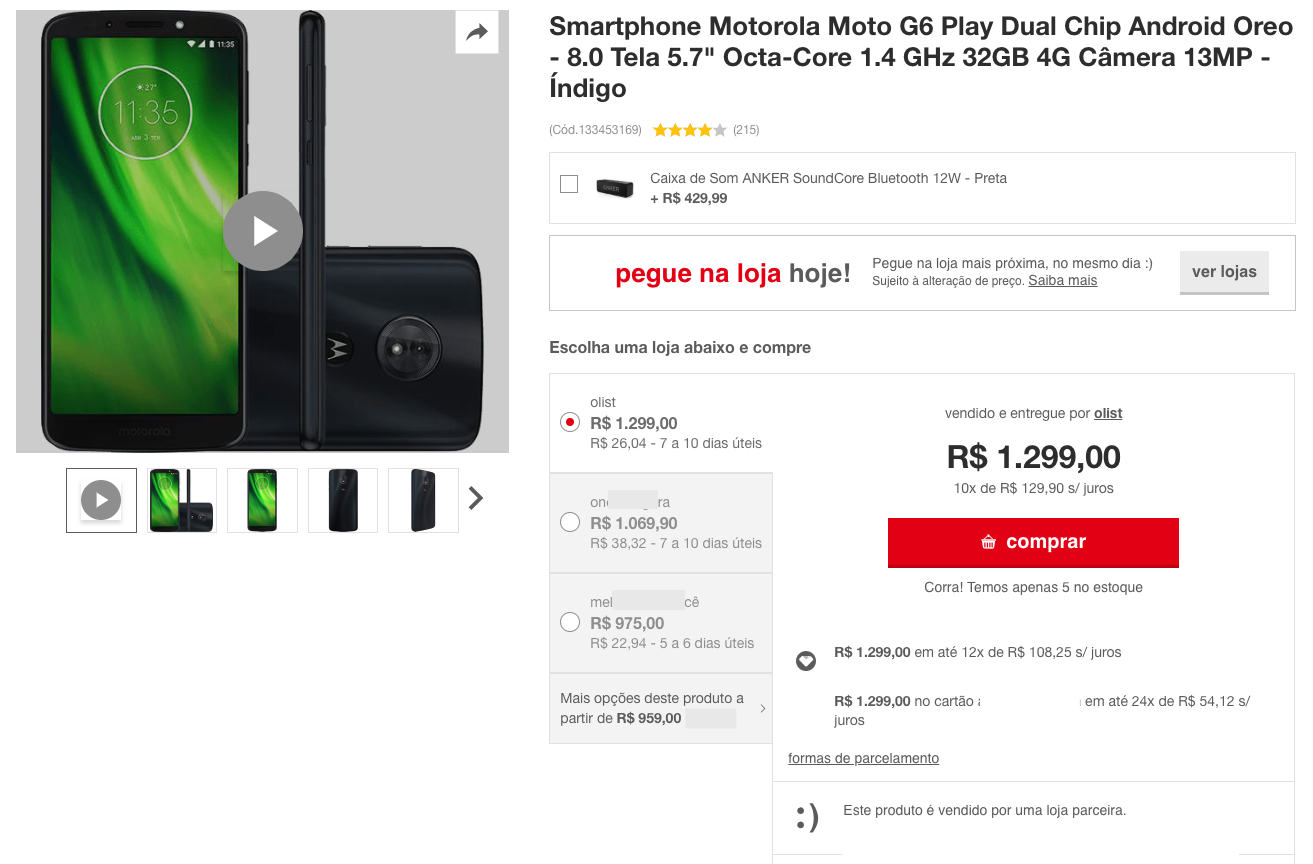

In [27]:
display(Image(filename=os.path.join(assets, 'product_listing_example.png'), width=800))

<div align="center">
  <p style="color: grey; font-style: italic;">
    Figure 2: Example of a Product Listing on the Marketplace
  </p>
</div>

---
## Data Schema & Relationships
The dataset consists of multiple tables linked through unique identifiers. The following schema (ERD) serves as our map for merging and joining data during the cleaning phase.

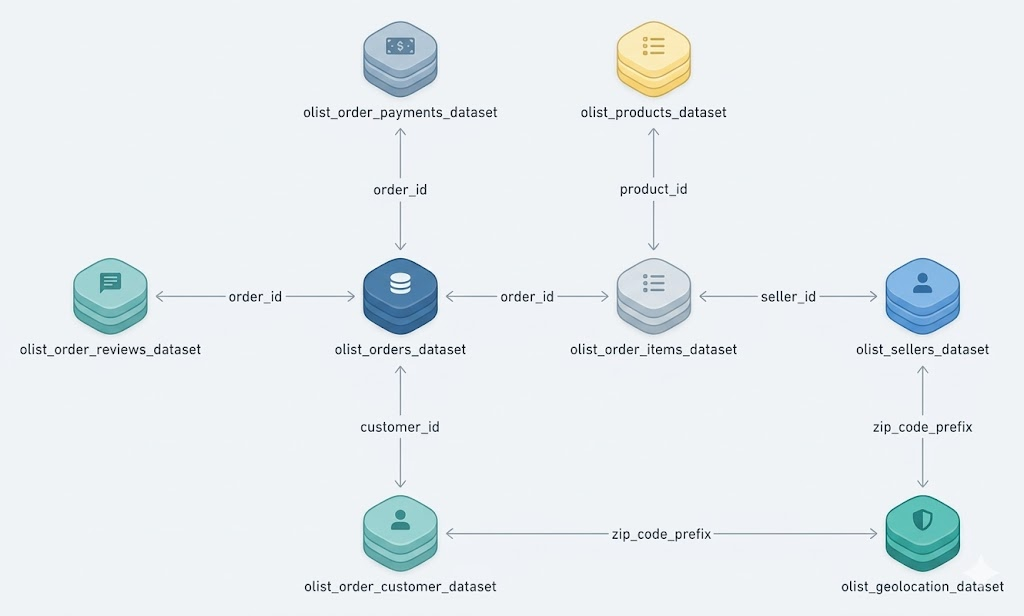

In [28]:
display(Image(filename=os.path.join(assets, 'olist_data_schema.jpg'), width=1000))

<div align="center">
  <p style="color: grey; font-style: italic;">
    Figure 3: Olist Dataset Schema & Table Relationships (ERD)
  </p>
</div>

---

## Data Dictionary

> Column descriptions are based on the official Olist dataset documentation.

---

### 1. olist_orders_dataset
One row = one unique order.

| Column | Description |
|--------|-------------|
| order_id | Unique identifier of the order |
| customer_id | Key to the customers dataset. Each order has a unique customer_id |
| order_status | Reference to the order status (delivered, shipped, etc) |
| order_purchase_timestamp | Shows the purchase timestamp |
| order_approved_at | Shows the payment approval timestamp |
| order_delivered_carrier_date | Shows the order posting timestamp. When it was handled to the logistic partner |
| order_delivered_customer_date | Shows the actual order delivery date to the customer |
| order_estimated_delivery_date | Shows the estimated delivery date that was informed to customer at the purchase moment |

---

### 2. olist_order_items_dataset
One row = one item within an order.

| Column | Description |
|--------|-------------|
| order_id | Unique identifier of the order |
| order_item_id | Sequential number identifying number of items included in the same order |
| product_id | Product unique identifier |
| seller_id | Seller unique identifier |
| shipping_limit_date | Shows the seller shipping limit date for handling the order over to the logistic partner |
| price | Item price |
| freight_value | Item freight value. If an order has more than one item the freight value is splitted between items |

---

### 3. olist_order_payments_dataset
One row = one payment transaction for an order.

| Column | Description |
|--------|-------------|
| order_id | Unique identifier of an order |
| payment_sequential | A customer may pay an order with more than one payment method. If he does so, a sequence will be created to accommodate all payments |
| payment_type | Method of payment chosen by the customer |
| payment_installments | Number of installments chosen by the customer |
| payment_value | Transaction value |

---

### 4. olist_order_reviews_dataset
One row = one customer review for an order.

| Column | Description |
|--------|-------------|
| review_id | Unique review identifier |
| order_id | Unique order identifier |
| review_score | Note ranging from 1 to 5 given by the customer on a satisfaction survey |
| review_comment_title | Comment title from the review left by the customer, in Portuguese |
| review_comment_message | Comment message from the review left by the customer, in Portuguese |
| review_creation_date | Shows the date in which the satisfaction survey was sent to the customer |
| review_answer_timestamp | Shows satisfaction survey answer timestamp |

---

### 5. olist_customers_dataset
One row = one unique customer.

| Column | Description |
|--------|-------------|
| customer_id | Key to the orders dataset. Each order has a unique customer_id |
| customer_unique_id | Unique identifier of a customer |
| customer_zip_code_prefix | First five digits of customer zip code |
| customer_city | Customer city name |
| customer_state | Customer state |

---

### 6. olist_sellers_dataset
One row = one unique seller.

| Column | Description |
|--------|-------------|
| seller_id | Seller unique identifier |
| seller_zip_code_prefix | First 5 digits of seller zip code |
| seller_city | Seller city name |
| seller_state | Seller state |

---

### 7. olist_products_dataset
One row = one unique product.

| Column | Description |
|--------|-------------|
| product_id | Unique product identifier |
| product_category_name | Root category of product, in Portuguese |
| product_name_lenght | Number of characters extracted from the product name |
| product_description_lenght | Number of characters extracted from the product description |
| product_photos_qty | Number of product published photos |
| product_weight_g | Product weight measured in grams |
| product_length_cm | Product length measured in centimeters |
| product_height_cm | Product height measured in centimeters |
| product_width_cm | Product width measured in centimeters |

---

### 8. olist_geolocation_dataset
One row = one zip code to coordinates mapping.

| Column | Description |
|--------|-------------|
| geolocation_zip_code_prefix | First 5 digits of zip code |
| geolocation_lat | Latitude |
| geolocation_lng | Longitude |
| geolocation_city | City name |
| geolocation_state | State |

---

### 9. product_category_name_translation
One row = one category name translation.

| Column | Description |
|--------|-------------|
| product_category_name | Category name in Portuguese |
| product_category_name_english | Category name in English |

---

## Setup and Imports

In [29]:
# ── Libraries ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ── Display Settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

warnings.filterwarnings('ignore')

## Dataset Overview

The dataset consists of 9 CSV files. Each file represents a different 
dimension of the order lifecycle.

In [30]:
# ── Olist E-Commerce Dataset - Data Loading ──────────────────────────────────

# Define path to raw data
DATA_PATH = '../data/raw/'

# Load all tables
orders      = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
items       = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
payments    = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews     = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
customers   = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
sellers     = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
products    = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
geolocation = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')
translation = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

# Print shape of each
tables = {
    'orders'      : orders,
    'items'       : items,
    'payments'    : payments,
    'reviews'     : reviews,
    'customers'   : customers,
    'sellers'     : sellers,
    'products'    : products,
    'geolocation' : geolocation,
    'translation' : translation
}

for name, df in tables.items():
    print(f"{name:15} {df.shape[0]:>10,} rows | {df.shape[1]:>2} columns")

orders              99,441 rows |  8 columns
items              112,650 rows |  7 columns
payments           103,886 rows |  5 columns
reviews             99,224 rows |  7 columns
customers           99,441 rows |  5 columns
sellers              3,095 rows |  4 columns
products            32,951 rows |  9 columns
geolocation      1,000,163 rows |  5 columns
translation             71 rows |  2 columns


| File | Rows | Columns | One row represents |
|------|------|---------|---------------------|
| olist_orders_dataset.csv | 99,441 | 8 | One unique order |
| olist_order_items_dataset.csv | 112,650 | 7 | One item within an order |
| olist_order_payments_dataset.csv | 103,886 | 5 | One payment transaction |
| olist_order_reviews_dataset.csv | 99,224 | 7 | One customer review |
| olist_customers_dataset.csv | 99,441 | 5 | One unique customer |
| olist_sellers_dataset.csv | 3,095 | 4 | One unique seller |
| olist_products_dataset.csv | 32,951 | 9 | One unique product |
| olist_geolocation_dataset.csv | 1,000,163 | 5 | One zip code to lat/lng mapping |
| product_category_name_translation.csv | 71 | 2 | One category name translation |

> **Note:** `olist_orders_dataset` is the central table.
> All other tables connect to it directly or indirectly through shared keys.

**Key observations:**

- `olist_order_items_dataset` has more rows than `olist_orders_dataset` (112,650 vs 99,441),
  meaning some orders contain multiple items.
- `olist_order_payments_dataset` also exceeds the orders count (103,886 vs 99,441),
  meaning some orders were paid using more than one payment method.

Both cases are expected based on the dataset documentation and will be handled during merging.

---

### Target Variable

`is_late` will be derived from two columns in the orders table:
- `is_late = 1` if `order_delivered_customer_date` > `order_estimated_delivery_date`
- `is_late = 0` otherwise

This column will be created **after** handling missing values to avoid NaN contamination.

---
## Data Preview

In [31]:
# ── Data Preview ─────────────────────────────────────────────────────────────
for name, df in tables.items():
    print(f"\n{'='*60}")
    print(f"  {name}  —  {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"{'='*60}")
    print(df.head(3))


  orders  —  99,441 rows x 8 columns
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  
2           2018-09-04 00:00:00  

  items  —  112,65

**A few observations from the data preview:**

- All tables loaded correctly with the expected structure.
- Several tables contain date and timestamp columns. Their data types need to be verified
  to ensure they are handled correctly in the analysis.
- `reviews`: `review_comment_title` and `review_comment_message` show NaN values
  from the first rows, confirming missing data in these columns.
- `products`: category names are in Portuguese — will need translation later.
- `geolocation`: first rows all belong to Sao Paulo, which is expected as it is
  the largest city in Brazil.

---
## Understand the Data

In [32]:
# ── Descriptive Statistics (Numeric Columns) ──────────────────────────────────
print("=" * 60)
print("  DESCRIPTIVE STATISTICS SUMMARY")
print("  (count, mean, std, min, 25%, 50%, 75%, max)")
print("=" * 60)

for name, df in tables.items():
    numeric_cols = df.select_dtypes(include='number')
    if numeric_cols.empty:
        print(f"\n {name}: No numeric columns found.")
        continue
    print(f"\n{'='*60}")
    print(f"  {name}  —  {numeric_cols.shape[1]} numeric column(s)")
    print(f"{'='*60}")
    print(numeric_cols.describe().T.to_string())

  DESCRIPTIVE STATISTICS SUMMARY
  (count, mean, std, min, 25%, 50%, 75%, max)

 orders: No numeric columns found.

  items  —  3 numeric column(s)
                  count   mean    std  min   25%   50%    75%     max
order_item_id 112650.00   1.20   0.71 1.00  1.00  1.00   1.00   21.00
price         112650.00 120.65 183.63 0.85 39.90 74.99 134.90 6735.00
freight_value 112650.00  19.99  15.81 0.00 13.08 16.26  21.15  409.68

  payments  —  3 numeric column(s)
                         count   mean    std  min   25%    50%    75%      max
payment_sequential   103886.00   1.09   0.71 1.00  1.00   1.00   1.00    29.00
payment_installments 103886.00   2.85   2.69 0.00  1.00   1.00   4.00    24.00
payment_value        103886.00 154.10 217.49 0.00 56.79 100.00 171.84 13664.08

  reviews  —  1 numeric column(s)
                count  mean  std  min  25%  50%  75%  max
review_score 99224.00  4.09 1.35 1.00 4.00 5.00 5.00 5.00

  customers  —  1 numeric column(s)
                            coun

In [33]:
# ── Data Types and Missing Values per Table ───────────────────────────────────
for name, df in tables.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    missing = df.isnull().sum()
    dtypes  = df.dtypes
    summary = pd.DataFrame({'dtype': dtypes, 'missing': missing})
    print(summary)


  orders
                                dtype  missing
order_id                       object        0
customer_id                    object        0
order_status                   object        0
order_purchase_timestamp       object        0
order_approved_at              object      160
order_delivered_carrier_date   object     1783
order_delivered_customer_date  object     2965
order_estimated_delivery_date  object        0

  items
                       dtype  missing
order_id              object        0
order_item_id          int64        0
product_id            object        0
seller_id             object        0
shipping_limit_date   object        0
price                float64        0
freight_value        float64        0

  payments
                        dtype  missing
order_id               object        0
payment_sequential      int64        0
payment_type           object        0
payment_installments    int64        0
payment_value         float64        0

  revie

---
## Initial Exploration

After loading all tables, two categories of issues were found:

### Issue 1 — Data Types
All timestamp columns were read as `object` instead of `datetime`. This affects:
- `orders`: `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`,
  `order_delivered_customer_date`, `order_estimated_delivery_date`
- `items`: `shipping_limit_date`
- `reviews`: `review_creation_date`, `review_answer_timestamp`

### Issue 2 — Missing Values
Missing values found in: `orders`, `reviews`, and `products` (detailed below).

---
## Data Cleaning

### Fix Data Types

We convert all date columns from `object` to `datetime64` **before** any flag creation,
so that all downstream date arithmetic is correct.

In [34]:
# ── Fix Data Types ───────────────────────────────────────────────────
# WHY: All date columns arrive as `object` (string). Without datetime conversion,
# date arithmetic (is_late, delivery_days, time deltas) is impossible.

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# items
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])

# reviews
reviews['review_creation_date']    = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

print("✓ Date conversion complete.")
print(orders[date_columns].dtypes.to_string())

✓ Date conversion complete.
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]


---

### Order Status Analysis

Before applying any filters, we analyze the distribution of `order_status` to understand:
1. Which statuses exist in the raw data
2. How complete the delivery timestamps are for each status
3. Why we filter to `delivered` orders only

This analysis justifies the scope restriction applied in the next step.

In [35]:
# ── Order Status Distribution — BEFORE any filtering ──────────────────────────
# WHY: Document what statuses exist and their timestamp completeness.
# This justifies filtering to 'delivered' orders only.

print("=" * 80)
print("ORDER STATUS DISTRIBUTION - RAW DATA (BEFORE FILTERING)")
print("=" * 80)

print(f"\nTotal orders: {len(orders):,}\n")

# Full distribution
status_counts = orders['order_status'].value_counts()
status_pct = orders['order_status'].value_counts(normalize=True) * 100

print("Distribution:")
for status, count in status_counts.items():
    pct = status_pct[status]
    print(f"  {status:15s}: {count:6,} ({pct:5.2f}%)")

# Check timestamp completeness per status
print("\n" + "=" * 80)
print("TIMESTAMP COMPLETENESS BY STATUS")
print("=" * 80)
print("Column: order_delivered_customer_date (required to compute is_late)\n")

for status in status_counts.index:
    subset = orders[orders['order_status'] == status]
    missing_delivery = subset['order_delivered_customer_date'].isnull().sum()
    missing_pct = (missing_delivery / len(subset)) * 100
    
    print(f"{status:15s} ({len(subset):6,} orders): {missing_delivery:6,} missing ({missing_pct:5.1f}%)")

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
print("Only 'delivered' status has complete timestamps needed for is_late.")
print("All other statuses (shipped, canceled, etc.) lack delivery dates.")
print("→ Scope filter: Keep only order_status == 'delivered'")
print("=" * 80)


ORDER STATUS DISTRIBUTION - RAW DATA (BEFORE FILTERING)

Total orders: 99,441

Distribution:
  delivered      : 96,478 (97.02%)
  shipped        :  1,107 ( 1.11%)
  canceled       :    625 ( 0.63%)
  unavailable    :    609 ( 0.61%)
  invoiced       :    314 ( 0.32%)
  processing     :    301 ( 0.30%)
  created        :      5 ( 0.01%)
  approved       :      2 ( 0.00%)

TIMESTAMP COMPLETENESS BY STATUS
Column: order_delivered_customer_date (required to compute is_late)

delivered       (96,478 orders):      8 missing (  0.0%)
shipped         ( 1,107 orders):  1,107 missing (100.0%)
canceled        (   625 orders):    619 missing ( 99.0%)
unavailable     (   609 orders):    609 missing (100.0%)
invoiced        (   314 orders):    314 missing (100.0%)
processing      (   301 orders):    301 missing (100.0%)
created         (     5 orders):      5 missing (100.0%)
approved        (     2 orders):      2 missing (100.0%)

CONCLUSION
Only 'delivered' status has complete timestamps needed f

---

### Handle Missing Values

Missing values were handled differently depending on their source and impact.
After timestamp cleanup, a **scope filter** is applied to restrict the dataset
to orders that completed the full delivery lifecycle.

**Rationale:** The analysis above shows that only `delivered` orders have the complete
timestamp data required to compute `is_late`. All other statuses (`shipped`, `canceled`, etc.)
lack `order_delivered_customer_date`, making them unusable for our prediction task.

| Table | Column(s) | Strategy | Reason |
|-------|-----------|----------|--------|
| `orders` | `order_delivered_customer_date`, `order_approved_at`, `order_delivered_carrier_date` | Drop rows | Cannot compute `is_late` or delivery duration without complete timestamps |
| `orders` | `order_status ≠ 'delivered'` | Drop rows | **Project scope:** predict delivery delays for completed orders only. Statuses like `shipped`, `canceled`, `invoiced` either never completed or cannot be reliably labeled (see analysis above). |
| `reviews` | `review_comment_message` | Fill → `'no_comment'` | Absence of a message does not indicate sentiment; `review_score` carries that |
| `reviews` | `review_comment_title` | Fill → `'no_title'` | Same reasoning — titles are optional |
| `products` | `product_category_name` | Fill → `'unknown'` | Preserves 610 valid products for analysis |
| `products` | `product_name_lenght`, `product_description_lenght`, `product_photos_qty` | Fill → column median | All 610 belong to the same uncategorised block |
| `products` | `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` | Drop rows | Cannot impute physical shipping dimensions (only 2 rows affected) |


In [36]:
# ── Handle Missing Values ────────────────────────────────────────────

# --- orders ---
# Step 1: Drop rows with incomplete delivery timestamps.
# Without these three columns, is_late and delivery duration cannot be computed.
initial_orders = len(orders)
orders = orders.dropna(subset=[
    'order_delivered_customer_date',
    'order_approved_at',
    'order_delivered_carrier_date'
])
after_dropna = len(orders)
print(f"Step 1 — dropna: dropped {initial_orders - after_dropna:,} rows with incomplete timestamps → {after_dropna:,} retained.")

# Step 2: Restrict to delivered orders only.
# Project scope is predicting delivery delays for orders that completed the full lifecycle.
# All other statuses (shipped, canceled, invoiced, processing, approved, unavailable, created)
# either never reached the customer or cannot be reliably labeled as late or on-time.
# Note: most non-delivered orders are already gone after Step 1 (no delivery timestamp).
# This step catches rare edge cases where a non-delivered status has complete timestamps
# due to system logging anomalies (e.g. a canceled order with a recorded delivery date).
status_before = orders['order_status'].value_counts()
orders = orders[orders['order_status'] == 'delivered'].reset_index(drop=True)
print(f"Step 2 — scope filter: dropped {after_dropna - len(orders):,} non-delivered rows → {len(orders):,} retained.")
print(f"  Statuses removed: {dict(status_before[status_before.index != 'delivered'])}")

print(f"\nTotal orders dropped from original {initial_orders:,}: {initial_orders - len(orders):,}")
print(f"Final orders retained: {len(orders):,}")

# --- reviews ---
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('no_comment')
print("\nReviews: review_comment_message filled with 'no_comment'.")

reviews['review_comment_title'] = reviews['review_comment_title'].fillna('no_title')
print("Reviews: review_comment_title filled with 'no_title'.")

# --- products ---
products['product_category_name'] = products['product_category_name'].fillna('unknown')
print("Products: product_category_name filled with 'unknown'.")

for col in ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']:
    median_val = products[col].median()
    products[col] = products[col].fillna(median_val)
    print(f"Products: {col} filled with median ({median_val:.0f}).")

before = len(products)
products = products.dropna(subset=[
    'product_weight_g', 'product_length_cm',
    'product_height_cm', 'product_width_cm'
])
print(f"Products: dropped {before - len(products)} rows with missing physical dimensions.")

print("\n✓ Missing value handling complete.")

# ── Verify: no remaining missing values in critical columns ───────────────────
print("\nVerification — remaining missing values in key tables:")
for name, df in [('orders', orders), ('reviews', reviews), ('products', products)]:
    remaining = df.isnull().sum().sum()
    print(f"  {name:12}: {remaining} missing values remaining")


Step 1 — dropna: dropped 2,980 rows with incomplete timestamps → 96,461 retained.
Step 2 — scope filter: dropped 6 non-delivered rows → 96,455 retained.
  Statuses removed: {'canceled': 6}

Total orders dropped from original 99,441: 2,986
Final orders retained: 96,455

Reviews: review_comment_message filled with 'no_comment'.
Reviews: review_comment_title filled with 'no_title'.
Products: product_category_name filled with 'unknown'.
Products: product_name_lenght filled with median (51).
Products: product_description_lenght filled with median (595).
Products: product_photos_qty filled with median (1).
Products: dropped 2 rows with missing physical dimensions.

✓ Missing value handling complete.

Verification — remaining missing values in key tables:
  orders      : 0 missing values remaining
  reviews     : 0 missing values remaining
  products    : 0 missing values remaining


---
### Create Delivery Flags

Flags are created **after** handling missing values to avoid NaN contamination
in boolean comparisons.

| Flag | Logic | Purpose |
|------|-------|---------|
| `is_late` | `delivered_date > estimated_date` → 1 | Binary target variable for the classification model |
| `is_delivered` | `order_status == 'delivered'` → 1 | Filter for orders that completed the full lifecycle |
| `delivery_status` | `'early'` / `'on_time'` / `'late'` | Richer 3-class label for EDA |



> **Note on `delivery_status`:** The `on_time` class requires exact timestamp equality
> between `order_delivered_customer_date` and `order_estimated_delivery_date`.
> Because estimated dates are stored as midnight (`00:00:00`) and actual delivery
> timestamps carry precise times, an exact `==` match is extremely rare in practice.
> In this dataset **`on_time` = 0 rows** — all delivered orders are either `early` or `late`.
> Use `is_late` (binary) as the primary target; `delivery_status` is retained for
> directional EDA only.

In [37]:
# ── Create Delivery Flags ────────────────────────────────────────────
# WHY: Created AFTER dropna so NaN rows cannot corrupt boolean comparisons.

# ── Flag 1: is_late — Binary target variable ──────────────────────────────────
orders['is_late'] = (
    orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']
).astype(int)

# ── Flag 2: is_delivered ──────────────────────────────────────────────────────
orders['is_delivered'] = (orders['order_status'] == 'delivered').astype(int)

# ── Flag 3: delivery_status — 3-class ─────────────────────────────────────────
orders['delivery_status'] = orders.apply(
    lambda row: 'early'   if row['order_delivered_customer_date'] < row['order_estimated_delivery_date']
           else 'on_time' if row['order_delivered_customer_date'] == row['order_estimated_delivery_date']
           else 'late',
    axis=1
)

print(f"✓ 'is_late' flag created.     Late orders     : {orders['is_late'].sum():,}")
print(f"✓ 'is_delivered' flag created. Delivered orders: {orders['is_delivered'].sum():,}")

print(f"\ndelivery_status distribution:")
print(orders['delivery_status'].value_counts().to_string())

print(f"\nTarget variable balance:")
print(f"  On-time (is_late=0) : {(orders['is_late']==0).sum():>6,}  ({(orders['is_late']==0).mean()*100:.1f}%)")
print(f"  Late    (is_late=1) : {(orders['is_late']==1).sum():>6,}  ({orders['is_late'].mean()*100:.1f}%)")


✓ 'is_late' flag created.     Late orders     : 7,825
✓ 'is_delivered' flag created. Delivered orders: 96,455

delivery_status distribution:
delivery_status
early    88630
late      7825

Target variable balance:
  On-time (is_late=0) : 88,630  (91.9%)
  Late    (is_late=1) :  7,825  (8.1%)


---
###  Handle Impossible Values

Some values pass the missing-value check but are still impossible in the real world.
We fix or flag them here rather than deleting records blindly.

| Table | Column / Issue | What we found | Action | Why |
|-------|---------------|---------------|--------|-----|
| `products` | `product_weight_g = 0` | 4 rows with zero weight | Replace with median of valid weights | Physical goods cannot weigh 0g. Median chosen over mean because weight is right-skewed. |
| `items` | `price > mean + 3σ` | 1,966 items (1.74%) | Flag as `is_high_value = 1` | High prices are legitimate (electronics, furniture). Keep for model; treat in Feature Engineering. |
| `items` | `freight_value = 0` | 383 items | Flag as `is_zero_freight = 1` | Free shipping is unusual in Brazil. Could be entry error — investigate in EDA. |
| `geolocation` | Coordinates outside Brazil | 42 rows | Flag as `is_outside_brazil = 1` | Lat/lng pointing to Europe, Mexico, Philippines. Entry errors — exclude only when computing distances. |
| `customers`, `sellers`, `geolocation` | Numeric/garbage city names | 1, 1, 12 rows | Flag as `is_valid_city = 0` | City names like `'12345'` break geolocation joins. Flagged, not removed. |

In [38]:
# ── Handle Impossible Values ─────────────────────────────────────────

# 1. product_weight_g = 0  →  replace with median of valid weights
# Physical goods cannot weigh 0g. Median is used because weight is right-skewed.
zero_weight_count = (products['product_weight_g'] == 0).sum()
median_weight     = products.loc[products['product_weight_g'] > 0, 'product_weight_g'].median()
products.loc[products['product_weight_g'] == 0, 'product_weight_g'] = median_weight
print(f"[products] weight = 0 → replaced {zero_weight_count} row(s) with median ({median_weight:.0f}g)")

# 2. Items: flag high-value prices and zero freight
# High prices are legitimate but exceptional — flag for separate treatment in Feature Engineering.
# Zero freight is unusual in Brazil — flag for EDA investigation.
price_mean           = items['price'].mean()
price_std            = items['price'].std()
high_value_threshold = price_mean + 3 * price_std
items['is_high_value']   = (items['price'] > high_value_threshold).astype(int)
items['is_zero_freight'] = (items['freight_value'] == 0).astype(int)
print(f"[items]    is_high_value   → {items['is_high_value'].sum():,} items above R${high_value_threshold:,.2f} (mean + 3σ)")
print(f"[items]    is_zero_freight → {items['is_zero_freight'].sum():,} items with freight = 0")

# 3. Geolocation: flag coordinates outside Brazil's bounding box
# Brazil bounding box — lat: -33.75 to +5.27 | lng: -73.99 to -34.79
# Anything outside = data entry error (we found coordinates in Europe, Mexico, Philippines).
# Flagged only — all rows retained. Exclude flagged rows when computing distances.
geolocation['is_outside_brazil'] = (
    (geolocation['geolocation_lat'] < -33.75) | (geolocation['geolocation_lat'] > 5.27) |
    (geolocation['geolocation_lng'] < -73.99) | (geolocation['geolocation_lng'] > -34.79)
).astype(int)
flagged = geolocation['is_outside_brazil'].sum()
print(f"[geoloc]   is_outside_brazil → {flagged} rows flagged out of {len(geolocation):,} (all retained)")

# 4. City name validation: flag numeric or garbage city names
# Names like '12345' break geolocation joins — flag, do not delete.
def is_valid_city(name):
    if pd.isna(name): return 0
    if len(str(name).strip()) < 2: return 0
    if any(c.isdigit() for c in str(name)): return 0
    return 1

customers['is_valid_city']   = customers['customer_city'].apply(is_valid_city)
sellers['is_valid_city']     = sellers['seller_city'].apply(is_valid_city)
geolocation['is_valid_city'] = geolocation['geolocation_city'].apply(is_valid_city)
print(f"[customers] is_valid_city = 0 → {(customers['is_valid_city']==0).sum()} row(s)")
print(f"[sellers]   is_valid_city = 0 → {(sellers['is_valid_city']==0).sum()} row(s)")
print(f"[geoloc]    is_valid_city = 0 → {(geolocation['is_valid_city']==0).sum()} row(s)")


[products] weight = 0 → replaced 4 row(s) with median (700g)
[items]    is_high_value   → 1,966 items above R$671.56 (mean + 3σ)
[items]    is_zero_freight → 383 items with freight = 0
[geoloc]   is_outside_brazil → 42 rows flagged out of 1,000,163 (all retained)
[customers] is_valid_city = 0 → 1 row(s)
[sellers]   is_valid_city = 0 → 1 row(s)
[geoloc]    is_valid_city = 0 → 12 row(s)


---
### Duplicate Audit

In [39]:
# ──  Duplicate Audit ──────────────────────────────────────────────────
# Update tables dict to reflect all cleaned versions
tables = {
    'orders': orders, 'items': items, 'payments': payments,
    'reviews': reviews, 'customers': customers, 'sellers': sellers,
    'products': products, 'geolocation': geolocation, 'translation': translation
}

duplicate_report = []
for name, df in tables.items():
    dup_count = df.duplicated().sum()
    duplicate_report.append({
        'Dataset'        : name,
        'Duplicate Rows' : dup_count,
        'Percentage (%)' : round((dup_count / len(df)) * 100, 2)
    })

dup_df = pd.DataFrame(duplicate_report)
print("Duplicate Audit Report:")
print(dup_df.sort_values(by='Duplicate Rows', ascending=False).to_string(index=False))

# ── Key-level duplicate check for reviews ────────────────────────────────────
print(f"\nReviews — duplicate review_id  : {reviews['review_id'].duplicated().sum():,}")
print(f"Reviews — orders with >1 review : {reviews['order_id'].duplicated().sum():,}")
print("→ Orders with multiple reviews will produce fan-out during merge — handle in 02_merging.ipynb")

Duplicate Audit Report:
    Dataset  Duplicate Rows  Percentage (%)
geolocation          261831           26.18
     orders               0            0.00
      items               0            0.00
   payments               0            0.00
    reviews               0            0.00
  customers               0            0.00
    sellers               0            0.00
   products               0            0.00
translation               0            0.00

Reviews — duplicate review_id  : 814
Reviews — orders with >1 review : 551
→ Orders with multiple reviews will produce fan-out during merge — handle in 02_merging.ipynb


**Duplicate Audit Summary:**
- **Transactional tables** (orders, items, payments, products): 0 full-row duplicates — all records are unique.
- **Geolocation**: 261,831 duplicate rows (26.18%). These are **not** errors — multiple entries per zip code
  are expected and needed for coordinate lookups. A deduplication strategy (e.g. mean coordinate per zip code)
  will be applied in `02_merging.ipynb` before distance feature computation to prevent join fan-out.
- **Reviews**: Checked at key level — orders with multiple reviews will be handled during merge.

---
### Logical Consistency Checks

We check for timestamp sequences that are physically impossible.
Suspicious rows are **flagged**, not dropped — the final decision is deferred to EDA
where we can investigate patterns before removing anything.

| Check | Condition | Why it matters |
|-------|-----------|----------------|
| 1 | Delivery before purchase | Physically impossible |
| 2 | Carrier handoff before payment approval | Ambiguous — could be a system logging delay, not a real error |
| 3 | Customer delivery before carrier handoff | Physically impossible |



>*Note:** Check 2 flagged ~1,350 rows. These are not deleted here because the Olist
> documentation does not guarantee strict ordering between carrier handoff and payment approval.
> Investigate in EDA before deciding whether to drop them.> *

In [40]:
# ── Logical Consistency Checks ───────────────────────────────────────
# Strategy: FLAG suspicious rows, do not drop.
# Check 2 (carrier < approval) is ambiguous — could reflect system logging delays.
# All flags are passed to EDA for investigation before any rows are removed.

# Check 1: delivery before purchase — physically impossible
mask1 = orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']

# Check 2: carrier handoff before payment approval — ambiguous, flag for EDA
mask2 = orders['order_delivered_carrier_date'] < orders['order_approved_at']

# Check 3: customer delivery before carrier handoff — physically impossible
mask3 = orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']

orders['has_timestamp_issue'] = (mask1 | mask2 | mask3).astype(int)

print("Logical consistency check results:")
print(f"  [1] Delivery < Purchase        : {mask1.sum()} rows")
print(f"  [2] Carrier < Approved at      : {mask2.sum()} rows")
print(f"  [3] Customer delivery < Carrier: {mask3.sum()} rows")
print(f"")
print(f"  Total flagged (has_timestamp_issue = 1): {orders['has_timestamp_issue'].sum()} rows")
print(f"  All {len(orders):,} rows retained — no rows dropped here.")


Logical consistency check results:
  [1] Delivery < Purchase        : 0 rows
  [2] Carrier < Approved at      : 1350 rows
  [3] Customer delivery < Carrier: 23 rows

  Total flagged (has_timestamp_issue = 1): 1373 rows
  All 96,455 rows retained — no rows dropped here.


 [2] Carrier < Approved at : 1350 rows ← ambiguous, investigate in EDA

---
### Create Delivery Duration & Review Polarity

In [41]:
# ── Create delivery_days & review_polarity ───────────────────────────

# ── delivery_days ─────────────────────────────────────────────────────────────
# WHY: Measures full logistics duration (purchase → customer delivery).
# Key numeric feature for the model.
# NOTE: .dt.days returns the integer floor of the timedelta.
# This means an order bought at 23:59 and delivered at 00:01 next day = 0 days.
# This rounding behaviour is noted and accepted for this project phase.
# Feature Engineering may switch to .dt.total_seconds() / 86400 for higher precision.

orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

print("✓ delivery_days created.")
print(orders['delivery_days'].describe(percentiles=[.25, .50, .75, .90, .95, .99]).to_string())

zero_delivery = (orders['delivery_days'] == 0).sum()
print(f"\n⚠  delivery_days = 0: {zero_delivery} rows (same-day delivery or floor-rounding artifact)")
print("   → Investigate in EDA before use as a feature.")

# ── review_polarity ───────────────────────────────────────────────────────────
# WHY: review_score (1–5) is ordinal. Binary polarity enables quick sentiment splits.
#   4–5 = positive  |  1–3 = negative
reviews['review_polarity'] = reviews['review_score'].apply(
    lambda s: 'positive' if s >= 4 else 'negative'
)
print(f"\n✓ review_polarity created.")
print(reviews['review_polarity'].value_counts().to_string())

✓ delivery_days created.
count   96455.00
mean       12.09
std         9.55
min         0.00
25%         6.00
50%        10.00
75%        15.00
90%        23.00
95%        29.00
99%        46.00
max       209.00

⚠  delivery_days = 0: 13 rows (same-day delivery or floor-rounding artifact)
   → Investigate in EDA before use as a feature.

✓ review_polarity created.
review_polarity
positive    76470
negative    22754


---
### Outlier Investigation

count   96455.00
mean       12.09
std         9.55
min         0.00
25%         6.00
50%        10.00
75%        15.00
90%        23.00
95%        29.00
99%        46.00
max       209.00
Name: delivery_days, dtype: float64

Max delivery: 209 days


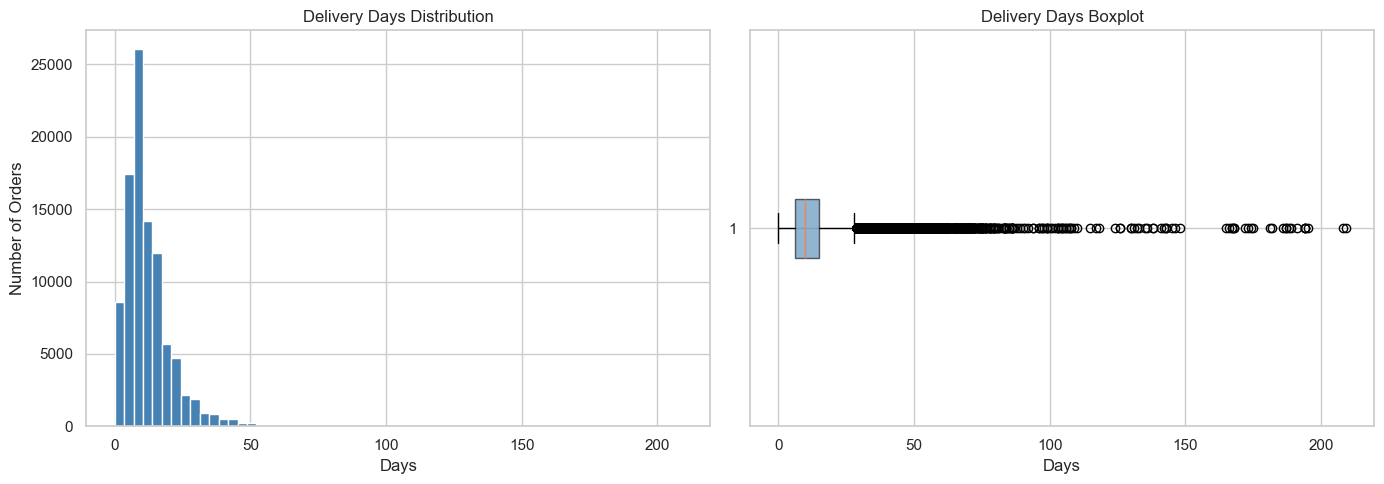

In [42]:
# ──  Delivery Days — Outlier Analysis ────────────────────────────────
print(orders['delivery_days'].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
print(f"\nMax delivery: {orders['delivery_days'].max()} days")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(orders['delivery_days'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Delivery Days Distribution')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Orders')

axes[1].boxplot(orders['delivery_days'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Delivery Days Boxplot')
axes[1].set_xlabel('Days')

plt.tight_layout()
plt.show()

In [43]:
# ──  Extreme Delivery Outlier Composition ────────────────────────────
threshold      = orders['delivery_days'].quantile(0.99)
extreme        = orders[orders['delivery_days'] > threshold]

print(f"99th percentile threshold : {threshold:.0f} days")
print(f"Extreme outliers (> {threshold:.0f}d) : {len(extreme):,} rows ({len(extreme)/len(orders)*100:.2f}%)")
print()
print("=== Composition of extreme delivery orders ===")
print(extreme['is_late'].value_counts())
print()
print(extreme['is_late'].value_counts(normalize=True).mul(100).round(1))

99th percentile threshold : 46 days
Extreme outliers (> 46d) : 879 rows (0.91%)

=== Composition of extreme delivery orders ===
is_late
1    848
0     31
Name: count, dtype: int64

is_late
1   96.50
0    3.50
Name: proportion, dtype: float64


### Finding — Outlier Decision

**96.5%** of orders with `delivery_days > 46` are **confirmed late deliveries**, not data anomalies.
These represent the hardest real-world cases the model needs to learn from.

| # | Problem with removing them | Impact |
|---|---------------------------|--------|
| 1 | Strip 848 confirmed late cases from training data | Model never sees extreme delays |
| 2 | Artificially deflate late delivery rate | Distorted class balance |
| 3 | Bias the model toward short, easy deliveries | Poor generalisation |
| 4 | Lose the hardest high-risk cases entirely | Reduced business value |

**Decision: RETAIN all orders.** Outlier treatment for `delivery_days` deferred to Feature Engineering (capping or log-transformation at the feature level).

Price Outlier Summary (IQR Method)
Q1                : R$ 39.90
Q3                : R$ 134.90
IQR               : R$ 95.00
Lower bound       : R$ -102.60
Upper bound       : R$ 277.40
Max price         : R$ 6,735.00
Outlier count     : 8,427 rows (7.48% of items)

Top 10 highest prices:
0   6735.00
1   6729.00
2   6499.00
3   4799.00
4   4690.00
5   4590.00
6   4399.87
7   4099.99
8   4059.00
9   3999.90


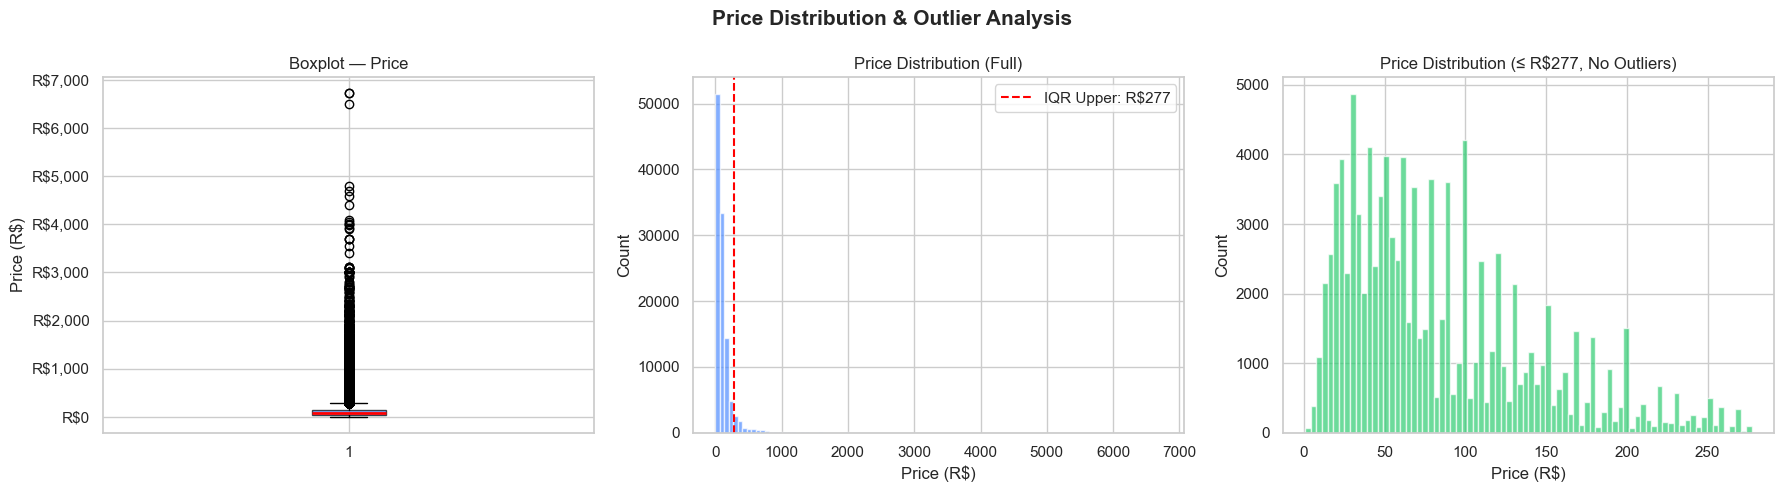


Decision: RETAIN all price outliers.
Reason   : High-priced items (electronics, furniture) are legitimate Olist orders.
Next step: Handle via log transformation or capping during Feature Engineering.


In [44]:
# ── Price Outlier Analysis (IQR Method) ─────────────────────────────
import matplotlib.ticker as mticker

Q1 = items['price'].quantile(0.25)
Q3 = items['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = items[items['price'] > upper_bound]
pct      = len(outliers) / len(items) * 100

print("=" * 55)
print("Price Outlier Summary (IQR Method)")
print("=" * 55)
print(f"Q1                : R$ {Q1:.2f}")
print(f"Q3                : R$ {Q3:.2f}")
print(f"IQR               : R$ {IQR:.2f}")
print(f"Lower bound       : R$ {lower_bound:.2f}")
print(f"Upper bound       : R$ {upper_bound:.2f}")
print(f"Max price         : R$ {items['price'].max():,.2f}")
print(f"Outlier count     : {len(outliers):,} rows ({pct:.2f}% of items)")
print()
print("Top 10 highest prices:")
print(items['price'].nlargest(10).reset_index(drop=True).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Price Distribution & Outlier Analysis', fontsize=15, fontweight='bold')

axes[0].boxplot(items['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4e8cff', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Boxplot — Price')
axes[0].set_ylabel('Price (R$)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

axes[1].hist(items['price'], bins=100, color='#4e8cff', alpha=0.7, edgecolor='white')
axes[1].axvline(upper_bound, color='red', linestyle='--', linewidth=1.5,
                label=f'IQR Upper: R${upper_bound:.0f}')
axes[1].set_title('Price Distribution (Full)')
axes[1].set_xlabel('Price (R$)')
axes[1].set_ylabel('Count')
axes[1].legend()

normal = items[items['price'] <= upper_bound]['price']
axes[2].hist(normal, bins=80, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[2].set_title(f'Price Distribution (≤ R${upper_bound:.0f}, No Outliers)')
axes[2].set_xlabel('Price (R$)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nDecision: RETAIN all price outliers.")
print("Reason   : High-priced items (electronics, furniture) are legitimate Olist orders.")
print("Next step: Handle via log transformation or capping during Feature Engineering.")

In [45]:
# ── Outlier Check — Items & Payments ────────────────────────────────
print("=== Items: price & freight_value ===")
print(items[['price', 'freight_value']].describe(percentiles=[.25, .50, .75, .90, .95, .99]))

zero_freight_count   = items['is_zero_freight'].sum()
print(f"\n⚠  freight_value = 0 : {zero_freight_count} rows (flagged as is_zero_freight)")

print("\n=== Payments: payment_value & payment_installments ===")
print(payments[['payment_value', 'payment_installments']].describe(
    percentiles=[.25, .50, .75, .90, .95, .99]))

zero_payment      = (payments['payment_value'] == 0).sum()
zero_installments = (payments['payment_installments'] == 0).sum()
print(f"\n⚠  payment_value = 0           : {zero_payment} rows (possible coupon/voucher orders)")
print(f"⚠  payment_installments = 0    : {zero_installments} rows (invalid — investigate)")

print("\n=== Products: physical dimensions ===")
print(products[['product_weight_g', 'product_length_cm',
                'product_height_cm', 'product_width_cm']].describe(
    percentiles=[.25, .50, .75, .90, .95, .99]))

=== Items: price & freight_value ===
          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
90%      229.80          34.04
95%      349.90          45.12
99%      890.00          84.52
max     6735.00         409.68

⚠  freight_value = 0 : 383 rows (flagged as is_zero_freight)

=== Payments: payment_value & payment_installments ===
       payment_value  payment_installments
count      103886.00             103886.00
mean          154.10                  2.85
std           217.49                  2.69
min             0.00                  0.00
25%            56.79                  1.00
50%           100.00                  1.00
75%           171.84                  4.00
90%           297.27                  8.00
95%           437.63                 10.00
99%          1039.92                 10.00


---

### Order Status Distribution After Cleaning

After applying:
1. `dropna()` on delivery timestamps
2. Scope filter: `order_status == 'delivered'`

We verify that only delivered orders remain in the cleaned dataset.


In [46]:
# ── Order Status Distribution — AFTER filtering ──────────────────────────────
# Verify that after both dropna and scope filter, only 'delivered' orders remain.

print("order_status distribution after cleaning:")
status_counts = orders['order_status'].value_counts()
status_pct    = orders['order_status'].value_counts(normalize=True).mul(100).round(2)
status_df     = pd.DataFrame({'count': status_counts, 'pct (%)': status_pct})
print(status_df.to_string())

print(f"\n✓ Scope filter successful: {status_counts.get('delivered', 0):,} delivered orders retained")
if len(status_counts) > 1:
    print(f"⚠ Warning: {len(status_counts) - 1} other status(es) found (edge cases that passed dropna)")


order_status distribution after cleaning:
              count  pct (%)
order_status                
delivered     96455   100.00

✓ Scope filter successful: 96,455 delivered orders retained


---
## Cleaning Summary

In [47]:
# ── Final Cleaning Summary ────────────────────────────────────────────────────
print("=" * 65)
print("  DATA CLEANING SUMMARY")
print("=" * 65)
print(f"  Original orders          :  99,441")
print(f"  Step 1 — dropna          :  dropped rows with incomplete timestamps")
print(f"  Step 2 — scope filter    :  restricted to order_status == 'delivered'")
print(f"  Final orders             :  {len(orders):>6,}  (delivered, complete lifecycle only)")
print()
print(f"  Target Variable (is_late):")
print(f"    On-time (is_late=0)    : {(orders['is_late']==0).sum():>6,}  ({(orders['is_late']==0).mean()*100:.1f}%)")
print(f"    Late    (is_late=1)    : {(orders['is_late']==1).sum():>6,}  ({orders['is_late'].mean()*100:.1f}%)")
print()
print(f"  Product Fixes:")
print(f"    product_weight_g = NaN : 2 rows dropped (missing physical dimensions)")
print(f"    product_weight_g = 0   : replaced with valid-median ({median_weight:.0f}g)")
print()
print(f"  Geolocation:")
print(f"    is_outside_brazil flag : {geolocation['is_outside_brazil'].sum():,} rows flagged (NOT removed)")
print(f"    All {len(geolocation):,} rows retained — filter per use-case downstream")
print()
print(f"  Flags Created:")
print(f"    orders.is_late            — 1 = delivered after estimated date (TARGET)")
print(f"    orders.is_delivered       — 1 = order_status == 'delivered' (all rows after scope filter)")
print(f"    orders.delivery_status    — 'early' / 'on_time' / 'late'")
print(f"    orders.delivery_days      — integer days from purchase to delivery")
print(f"    reviews.review_polarity   — 'positive' (≥4) / 'negative' (≤3)")
print(f"    items.is_high_value       — 1 if price > mean + 3σ")
print(f"    items.is_zero_freight     — 1 if freight_value == 0 (EDA flag)")
print(f"    customers.is_valid_city   — 1 = valid city name, 0 = suspicious")
print(f"    sellers.is_valid_city     — 1 = valid city name, 0 = suspicious")
print(f"    geolocation.is_valid_city      — 1 = valid, 0 = suspicious")
print(f"    geolocation.is_outside_brazil  — 1 = outside bounding box, 0 = valid")
print(f"    orders.has_timestamp_issue     — 1 = suspicious timestamp ordering (investigated in EDA)")
print()
print(f"  EDA Flags (investigate further in 03_EDA):")
print(f"    - items.is_zero_freight  = 1    ({items['is_zero_freight'].sum()} rows — free shipping or error?)")
print(f"    - payment_value = 0             ({(payments['payment_value']==0).sum()} rows — coupon/voucher?)")
print(f"    - payment_installments = 0      ({(payments['payment_installments']==0).sum()} rows — invalid, investigate)")
print(f"    - delivery_days = 0             ({(orders['delivery_days']==0).sum()} rows — same-day or floor artifact?)")
print(f"    - orders.has_timestamp_issue = 1 ({orders['has_timestamp_issue'].sum()} rows — reviewed in Notebook 03, Section 1.6)")
print("=" * 65)


  DATA CLEANING SUMMARY
  Original orders          :  99,441
  Step 1 — dropna          :  dropped rows with incomplete timestamps
  Step 2 — scope filter    :  restricted to order_status == 'delivered'
  Final orders             :  96,455  (delivered, complete lifecycle only)

  Target Variable (is_late):
    On-time (is_late=0)    : 88,630  (91.9%)
    Late    (is_late=1)    :  7,825  (8.1%)

  Product Fixes:
    product_weight_g = NaN : 2 rows dropped (missing physical dimensions)
    product_weight_g = 0   : replaced with valid-median (700g)

  Geolocation:
    is_outside_brazil flag : 42 rows flagged (NOT removed)
    All 1,000,163 rows retained — filter per use-case downstream

  Flags Created:
    orders.is_late            — 1 = delivered after estimated date (TARGET)
    orders.is_delivered       — 1 = order_status == 'delivered' (all rows after scope filter)
    orders.delivery_status    — 'early' / 'on_time' / 'late'
    orders.delivery_days      — integer days from purchase 

---

### Notes for EDA Team

1. **Target Variable:** `is_late` — **8.1%** late, **91.9%** on-time. Class imbalance must be addressed during modeling (SMOTE, `class_weight='balanced'`, or threshold tuning).
2. **`delivery_status` — `on_time` = 0 rows:** The `on_time` class does not appear in the data because `order_estimated_delivery_date` is stored as midnight (`00:00:00`) while actual delivery timestamps carry precise times. Use `is_late` (binary) as the model target; `delivery_status` is retained for directional EDA only.
3. **`has_timestamp_issue`:** 1,373 orders flagged with suspicious timestamp ordering (mainly carrier handoff before payment approval). **→ Investigated in Notebook 03, Section 1.6.** Decision: RETAIN all rows — Check 2 dominates and reflects a known Olist system logging behavior, not data corruption.
4. **`review_comment_title` / `review_comment_message`:** `'no_title'` and `'no_comment'` do **not** mean neutral — always use `review_score` for sentiment analysis.
5. **`product_category_name = 'unknown'`:** Check if these 610 products show patterns in delivery delays or freight costs.
6. **`delivery_days` outliers (> 46 days):** Retained intentionally — 96.5% are confirmed late deliveries. Apply capping or log-transformation in Feature Engineering.
7. **Price outliers:** Retained — legitimate high-value items. Apply transformation in Feature Engineering.
8. **Geolocation:** The full 1,000,163-row geolocation table is saved as `geolocation_clean.csv`. In `02_merging.ipynb`, coordinates are aggregated to one representative point per zip code (mean lat/lng) before joining to orders. The full table is available for spatial density analysis in EDA.

---

> **Next step:** `02_merging.ipynb` → Merge all 9 cleaned tables into one analysis-ready dataset before EDA begins.

In [48]:
# ── Save Cleaned Tables ──────────────────────────────────────────────────────
import os
os.makedirs('../data/processed/', exist_ok=True)

orders.to_csv('../data/processed/orders_clean.csv',           index=False)
items.to_csv('../data/processed/items_clean.csv',             index=False)
payments.to_csv('../data/processed/payments_clean.csv',       index=False)
reviews.to_csv('../data/processed/reviews_clean.csv',         index=False)
customers.to_csv('../data/processed/customers_clean.csv',     index=False)
sellers.to_csv('../data/processed/sellers_clean.csv',         index=False)
products.to_csv('../data/processed/products_clean.csv',       index=False)
geolocation.to_csv('../data/processed/geolocation_clean.csv', index=False)
translation.to_csv('../data/processed/translation_clean.csv', index=False)

print(" All cleaned tables saved to ../data/processed/")
print()
print("Files saved:")
for fname in ['orders_clean', 'items_clean', 'payments_clean', 'reviews_clean',
              'customers_clean', 'sellers_clean', 'products_clean',
              'geolocation_clean', 'translation_clean']:
    path = f'../data/processed/{fname}.csv'
    print(f"  {fname}.csv")

 All cleaned tables saved to ../data/processed/

Files saved:
  orders_clean.csv
  items_clean.csv
  payments_clean.csv
  reviews_clean.csv
  customers_clean.csv
  sellers_clean.csv
  products_clean.csv
  geolocation_clean.csv
  translation_clean.csv
